# Модель для предсказания массы морских черепах



### Конекст решаемой задачи
Проект по разработке портативной системы компьютерного зрения TurtleCV, которая будет с высокой точностью бесконтактно измерять габариты черепах, пока те находятся в реабилитационных бассейнах или на мелководье в естественной среде обитания.

Подсистема компьютерного зрения определяет:
- длину и ширину панциря в миллиметрах (мм);
- габариты головы (мм);
- габариты ласт (мм);
- количество колец на щитках панциря.

### Постановка задачи

Необходимо разработать модель линейной регрессии, которая будет использовать габариты и другие данные от TurtleCV для предсказания массы черепах.

Опытный образец модели разрабатывается для зелёных морских черепах **Chelonia mydas**

## Постановка задачи машинного обучения

В датасете есть историческая информация о значениях целевой переменной: 
- ***задача обучения с учителем***

Целевая переменная:
- ***масса черепахи***

Целевая переменная задается непрерывным числовым значением: 
- ***задача регрессии***

Модель должна быть ***линейной*** (исходя из требований)

Метрики качества модели: 
- MAE - основная (исходя из требований)
- $R^2$, MSE, MAPE - дополнительные
    
Критерии успешности: 
- MAE не более 5 кг
- модель хорошо предсказывает массу для черепах разного возраста и размера: MAPE на train и test не сильно отличаются
- $R^2 \ge 0.97$ для валидационной и тестовой выборках - модель объясняет большую часть вариативности массы

## Подключение и настройка библиотек

In [54]:
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from phik import phik_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.dummy import DummyRegressor

## Загрузка датасета

In [55]:
# Загрузка данных
df = pd.read_csv('https://code.s3.yandex.net/datasets/turtles.csv', sep='\t', decimal=',')

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

In [57]:
df.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


#### Наличие пропусков в данных:

In [58]:
df.isna().sum() / len(df) * 100

id                      0.000000
binomial_name           0.552985
registration number     0.327277
shell_length            0.981830
shell_width             0.000000
head_length             1.647670
head_width              1.647670
flipper_length_1        0.000000
flipper_width_1         0.000000
flipper_length_2        0.000000
flipper_width_2         0.000000
flipper_length_3        1.139826
flipper_width_3         1.139826
flipper_length_4        1.139826
flipper_width_4         1.139826
circle_count            0.000000
measure_count           2.979348
shell_crack            75.442952
timestamp               0.000000
weight                  0.214423
dtype: float64

In [59]:
# анализ для столбца с большой долей пропусков
df['shell_crack'].unique()

array([nan,  1.,  5.,  4.,  3.,  2.])

Для признака shell_crack нет значения 0, которе бы означало отсутствие трещин в панцире. 
Можно предположить, что отсутствие данных как раз это и означает.
Тогда, пропуски необходимо заменить на 0

In [60]:
## Дубликаты в данных
# явные
df.duplicated().sum() / df.shape[0] * 100

np.float64(11.499830718880487)

In [61]:
# поиск неявных дублей
df['binomial_name'].unique()

<StringArray>
[       'Caretta caretta',  'Lepidochelys olivacea',  'LEPIDOCHELYS OLIVACEA',
  'Lepidochelys Olivacea',  'lepidochelys olivacea',         'Chelonia mydas',
 'ERETMOCHELYS IMBRICATA', 'Eretmochelys imbricata',   'Dermochelys coriacea',
        'caretta caretta',        'CARETTA CARETTA',         'chelonia mydas',
         'Chelonia Mydas',         'CHELONIA MYDAS',   'Dermochelys Coriacea',
 'eretmochelys imbricata',                      nan,        'Caretta Caretta',
    'lepidochelys kempii',    'Lepidochelys kempii', 'Eretmochelys Imbricata',
   'dermochelys coriacea',    'Lepidochelys Kempii',   'DERMOCHELYS CORIACEA']
Length: 24, dtype: str

- есть дубли ввиду разного регистра

### Анализ:

Типы данных:
- типы данных соответствуют ожидаемым
- для всех количественных данных можно провести понижение размерности для экономии памяти 

Пропуски:
- менее 3% в столбцах: binomial_name, registration number, shell_length, head_length, head_width, flipper_length_3, flipper_width_3,  flipper_length_4, flipper_width_4, measure_count, weight. Эти пропуски можно заменить на характерные значения из выборки train
- около 75% в столбце shell_crack. Если предположить, что пропуски означают отсутствие трещин, то их необходимо заменить на 0.

Дубликаты:
- в данных 11.4% явных дубликатов. Явные дубли стоит удалить.
- обнаружены неявные дубли в binomial_name из-за разного регистра. Необходимо провести нормализацию данных к snake_case

**Вывод:**
- выгрузка проведена корректно, можно продолжать работу с данными
- сформулированы предложения по обработке данных

## Исследовательский анализ данных

#### Нормализация строковых данных

In [62]:
# номализация данных
def to_snake_case(value):
    """Преобразует одно значение в snake_case."""
    if pd.isna(value):
        return value
    s = str(value).strip().lower()
    s = re.sub(r"[^\w\s-]", "", s, flags=re.UNICODE)  
    s = re.sub(r"[\s\-]+", "_", s)                  
    s = re.sub(r"_+", "_", s).strip("_") 
    return s

def normalize_columns_snake_case(df, columns):
    """Нормализует указанные столбцы DataFrame в snake_case."""
    df = df.copy()
    for col in columns:
        df[col] = df[col].apply(to_snake_case)
    return df

In [63]:
# нормализация для binomial_name
df = normalize_columns_snake_case(df, ['binomial_name'])
# проверка нормализации
df['binomial_name'].unique()

<StringArray>
[       'caretta_caretta',  'lepidochelys_olivacea',         'chelonia_mydas',
 'eretmochelys_imbricata',   'dermochelys_coriacea',                      nan,
    'lepidochelys_kempii']
Length: 7, dtype: str

#### Обработка пропусков

In [64]:
df_init_len = len(df)
df.isna().sum() / len(df) * 100

id                      0.000000
binomial_name           0.552985
registration number     0.327277
shell_length            0.981830
shell_width             0.000000
head_length             1.647670
head_width              1.647670
flipper_length_1        0.000000
flipper_width_1         0.000000
flipper_length_2        0.000000
flipper_width_2         0.000000
flipper_length_3        1.139826
flipper_width_3         1.139826
flipper_length_4        1.139826
flipper_width_4         1.139826
circle_count            0.000000
measure_count           2.979348
shell_crack            75.442952
timestamp               0.000000
weight                  0.214423
dtype: float64

In [65]:
# предполагаем, что пропуски в shell_crack означают отсутствие трещин.
# Замена на 0
df['shell_crack'] = df['shell_crack'].fillna(0)

In [66]:
# удалим объекты с пропусками в целевой переменной weight (около 0.2%)
df.dropna(subset=['weight'], inplace=True)

- присутствуют малочисленные пропуски в других столбцах (до 3%). Оставляем для заполнения характерными значениями

#### Обработка дубликатов

In [67]:
df_init_len = len(df) 

df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [68]:
# потери при устранении явных дублей (%): 
(df_init_len - len(df)) / df_init_len * 100

11.501922641936213

#### Фильтрация данных
1. В рамках данной работы интересуют только chelonia_mydas. Оставляем только этот вид в датасете.
2. После фильтации по виду chelonia_mydas признак binomial_name не несет информации.
3. Признаки id, registration number полезны для идетификации конкретной особи, но не добавялют информации для выявления закономерностей.
4. Признаки timestamp и measure_count относятся к процессу сбора данных, но для анализа закономерностей бесполезны.


Остальные признаки являются количественными, характреризуют геометрию и внешний вид черепахи. Их оставляем для обучения модели.


In [69]:
df.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,caretta_caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,0.0,1703159226,87.687
1,19034,lepidochelys_olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,lepidochelys_olivacea,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,0.0,1745783111,30.016
3,17945,lepidochelys_olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys_olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


In [70]:
# оставляем только интересующий нас вид
df = df[df['binomial_name'] == 'chelonia_mydas']
# оставляем только нужную для обучения модели информацию
df = df.drop(columns=['id', 'binomial_name', 'registration number', 'timestamp', 'measure_count'])
df.head()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
8,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,1.0,56.352
11,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,5.0,154.074
16,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,0.0,87.695
20,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,1.0,51.182
21,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,0.0,92.707


#### Оптимизация по памяти для числовых данных

In [71]:
df.info()

<class 'pandas.DataFrame'>
Index: 2486 entries, 8 to 7840
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2457 non-null   float64
 1   shell_width       2486 non-null   int64  
 2   head_length       2451 non-null   float64
 3   head_width        2451 non-null   float64
 4   flipper_length_1  2486 non-null   int64  
 5   flipper_width_1   2486 non-null   int64  
 6   flipper_length_2  2486 non-null   int64  
 7   flipper_width_2   2486 non-null   int64  
 8   flipper_length_3  2457 non-null   float64
 9   flipper_width_3   2457 non-null   float64
 10  flipper_length_4  2457 non-null   float64
 11  flipper_width_4   2457 non-null   float64
 12  circle_count      2486 non-null   int64  
 13  shell_crack       2486 non-null   float64
 14  weight            2486 non-null   float64
dtypes: float64(9), int64(6)
memory usage: 310.8 KB


In [72]:
# преобразования типов, понижение размерностей
def downcast_type(col_name: str, type_name: str):
    return pd.to_numeric(df[col_name], downcast=type_name)

In [73]:
col_to_float_downcast = df.columns

for col in col_to_float_downcast:
    df[col] = downcast_type(col, 'float')

In [74]:
df.info()

<class 'pandas.DataFrame'>
Index: 2486 entries, 8 to 7840
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2457 non-null   float32
 1   shell_width       2486 non-null   float32
 2   head_length       2451 non-null   float32
 3   head_width        2451 non-null   float32
 4   flipper_length_1  2486 non-null   float32
 5   flipper_width_1   2486 non-null   float32
 6   flipper_length_2  2486 non-null   float32
 7   flipper_width_2   2486 non-null   float32
 8   flipper_length_3  2457 non-null   float32
 9   flipper_width_3   2457 non-null   float32
 10  flipper_length_4  2457 non-null   float32
 11  flipper_width_4   2457 non-null   float32
 12  circle_count      2486 non-null   float32
 13  shell_crack       2486 non-null   float32
 14  weight            2486 non-null   float32
dtypes: float32(15)
memory usage: 165.1 KB


#### Анализ распределения признаков

In [75]:
def boxplot_describe(data: pd.DataFrame, colnames: list[str]):
    sns.boxplot(data=data[colnames], orient="h")
    "head_length", "head_width"
    plt.grid()

    print(data[colnames].describe())

       shell_length   shell_width
count   2457.000000   2486.000000
mean    1047.963745    945.018127
std      568.694885    507.521179
min      645.000000    564.000000
25%      837.000000    752.250000
50%      980.000000    889.000000
75%     1172.000000   1056.000000
max    12840.000000  11550.000000


Text(0.5, 0, 'длина, мм')

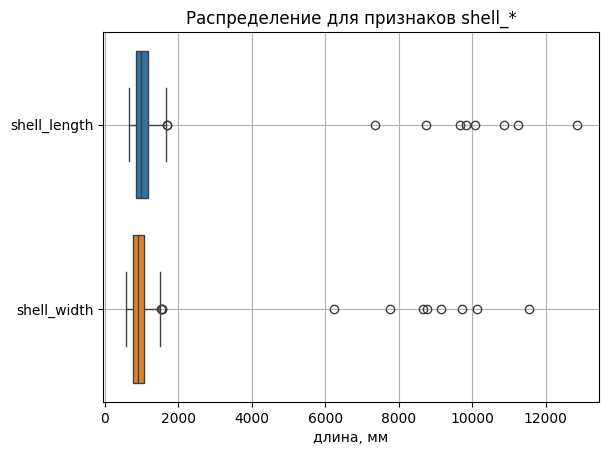

In [76]:
boxplot_describe(data=df, colnames=["shell_length", "shell_width"])
plt.title('Распределение для признаков shell_*')
plt.xlabel('длина, мм')

Анализ:
- выбросы на порядок отличаются от характерных значений в выборке. Это свидетельствует о наличии некорренктно записанных данных (коллега упоминал, что волонтер не в тех единицах записывал данные).

Решение:
- исправляем ошибки в данных: уменьшаем значение выбросов на порядок

In [77]:
def correct_dimentions(data: pd.DataFrame, col_name: str, threshold: float, mult: float):
    mask = data[col_name] > threshold
    data.loc[mask, col_name] = data.loc[mask, col_name] * mult
    return data

**shell**:

In [78]:
df = correct_dimentions(data=df, col_name="shell_length", threshold=2000, mult=0.1)
df = correct_dimentions(data=df, col_name="shell_width", threshold=2000, mult=0.1)

       shell_length  shell_width
count   2457.000000  2486.000000
mean    1018.436279   918.970215
std      222.149475   203.241547
min      645.000000   564.000000
25%      837.000000   752.000000
50%      979.000000   887.000000
75%     1168.000000  1054.000000
max     1683.000000  1554.000000


Text(0.5, 0, 'длина, мм')

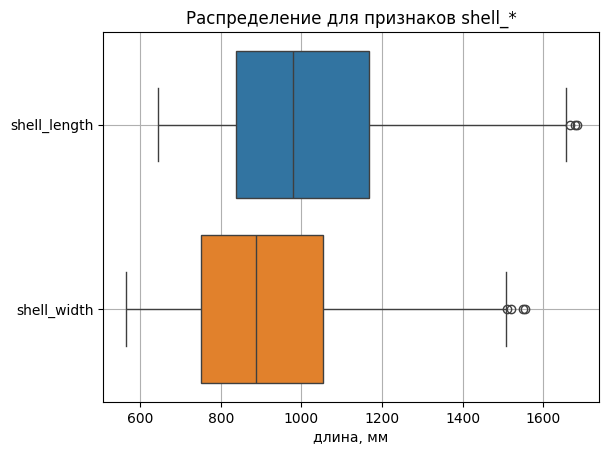

In [79]:
boxplot_describe(data=df, colnames=["shell_length", "shell_width"])
plt.title('Распределение для признаков shell_*')
plt.xlabel('длина, мм')

- после исправления выбросов распределения более симметричные и близкие по диапазону значений

**head**:

       head_length   head_width
count  2451.000000  2451.000000
mean    169.723373   183.321091
std      41.335453    45.477539
min      87.000000    96.000000
25%     138.000000   148.000000
50%     163.000000   176.000000
75%     195.000000   212.000000
max     328.000000   382.000000


Text(0.5, 0, 'длина, мм')

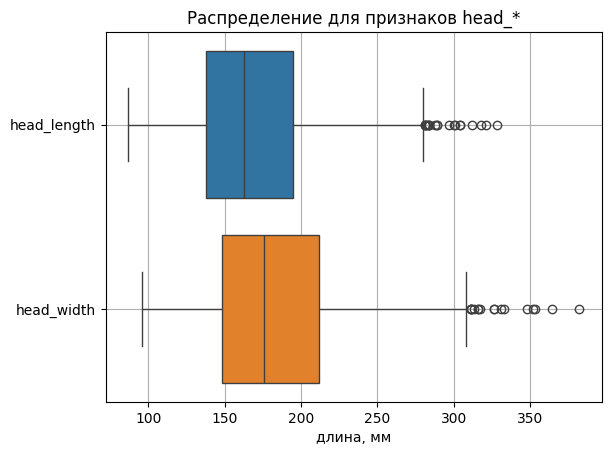

In [80]:
boxplot_describe(data=df, colnames=["head_length", "head_width"])
plt.title('Распределение для признаков head_*')
plt.xlabel('длина, мм')

- сильных выбросов нет. Корректирова не требуется

**flipper_length**, **flipper_width_**


       flipper_length_1  flipper_length_2  flipper_length_3  flipper_length_4
count       2486.000000       2486.000000       2457.000000       2457.000000
mean         612.010437        611.890198        487.262909        489.176239
std          142.589523        138.991989        110.435272        112.562973
min          339.000000        327.000000        282.000000        254.000000
25%          502.000000        505.000000        400.000000        400.000000
50%          587.000000        591.000000        473.000000        473.000000
75%          702.000000        704.000000        558.000000        563.000000
max         1147.000000       1049.000000        934.000000        877.000000


Text(0.5, 0, 'длина, мм')

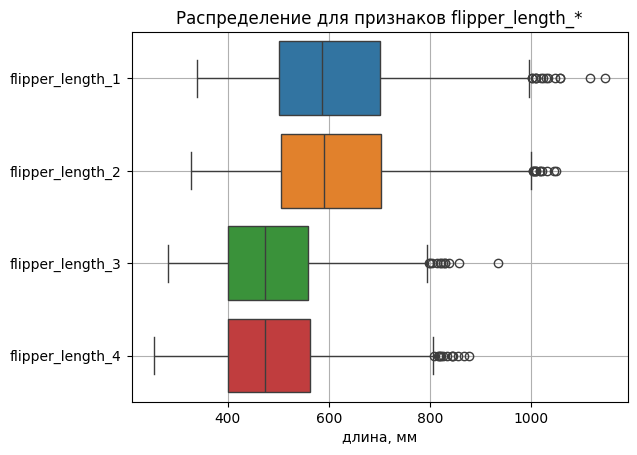

In [81]:
boxplot_describe(data=df, colnames=[f"flipper_length_{i}" for i in range(1, 5)])
plt.title('Распределение для признаков flipper_length_*')
plt.xlabel('длина, мм')

- аномально больших выбросов нет. Оставляем данные без изменений

       flipper_width_1  flipper_width_2  flipper_width_3  flipper_width_4
count      2486.000000      2486.000000      2457.000000      2457.000000
mean        549.364441       550.252991       440.667480       440.975159
std         131.859100       130.856308       105.532074       104.573837
min         245.000000       276.000000       231.000000       243.000000
25%         449.000000       449.000000       357.000000       359.000000
50%         527.000000       533.000000       425.000000       423.000000
75%         632.000000       635.000000       511.000000       509.000000
max        1072.000000       997.000000       837.000000       806.000000


Text(0.5, 0, 'длина, мм')

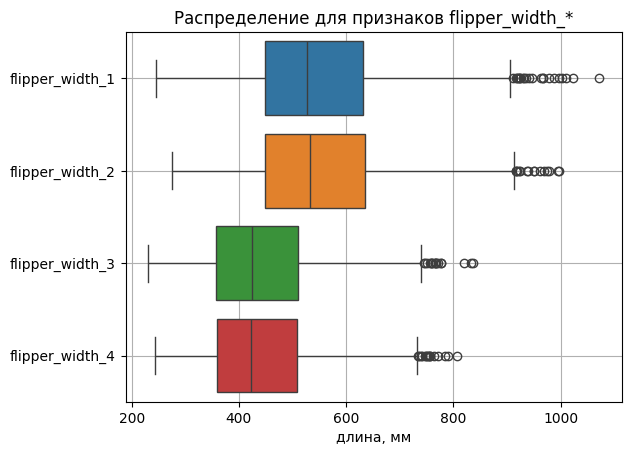

In [82]:
col_names = [f"flipper_width_{i}" for i in range(1, 5)]
boxplot_describe(data=df, colnames=col_names)
plt.title('Распределение для признаков flipper_width_*')
plt.xlabel('длина, мм')

- аномально больших выбросов нет. Оставляем данные без изменений


**circle_count**

       circle_count
count   2486.000000
mean      80.931618
std       16.228851
min       29.000000
25%       70.000000
50%       80.000000
75%       91.000000
max      143.000000


Text(0.5, 0, 'кол-во, шт.')

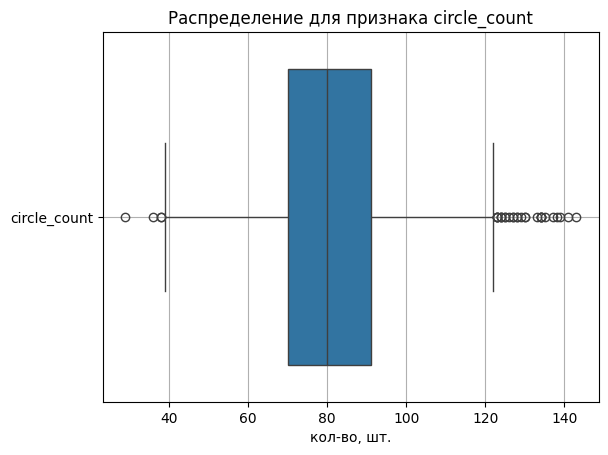

In [83]:
col_name = "circle_count"
boxplot_describe(data=df, colnames=[col_name])
plt.title(f'Распределение для признака {col_name}')
plt.xlabel('кол-во, шт.')

- аномально больших выбросов нет. Оставляем данные без изменений

**shell_crack**

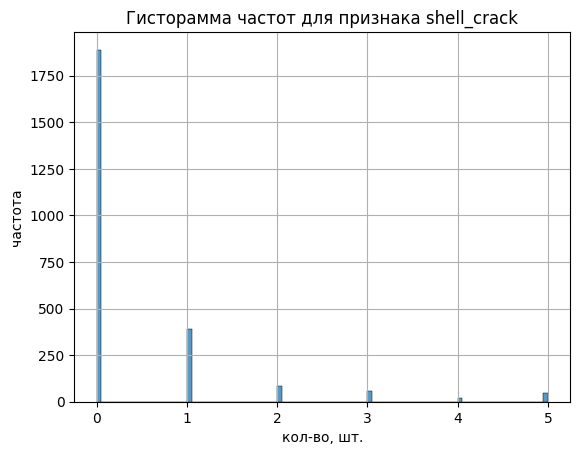

In [84]:
col_name = "shell_crack"
sns.histplot(data=df, x=col_name)
plt.title(f'Гисторамма частот для признака {col_name}')
plt.ylabel('частота')
plt.xlabel(f'кол-во, шт.')
plt.grid()

- у большинства черепах нет трещин. Пока оставляем этот признак

**weight**

            weight
count  2486.000000
mean     96.068855
std      35.149433
min       0.000000
25%      67.500751
50%      87.900002
75%     117.629501
max     199.960999


Text(0.5, 0, 'масса, кг.')

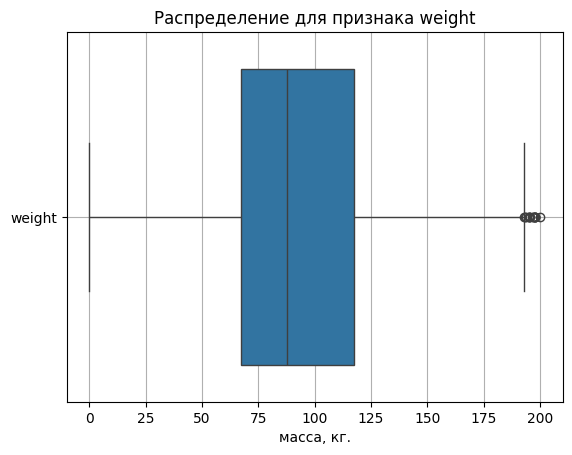

In [85]:
col_name = "weight"
boxplot_describe(data=df, colnames=[col_name])
plt.title(f'Распределение для признака {col_name}')
plt.xlabel(f'масса, кг.')

- выбросов мало, распределение довольно симметричное.
- встречаются нули, что может говорить об ошибках в данных. Необходимо дополнительно исследовать это значение целевой метрики

Процент выбросов с около нулевым значением:  0.12067578439259855


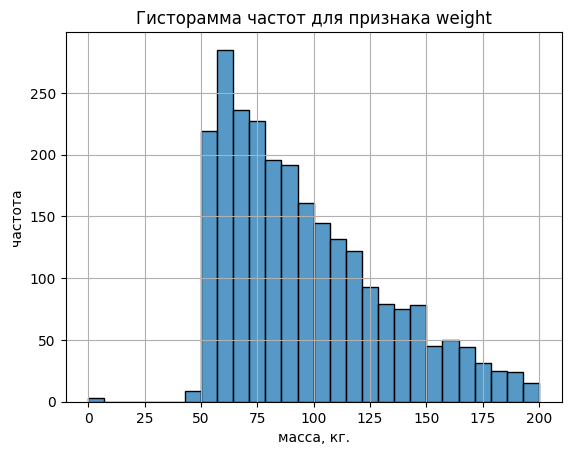

In [86]:
# Исследуем значения 0 в данных целевой метрики weight
col_name = "weight"
sns.histplot(data=df, x=col_name)
plt.title(f'Гисторамма частот для признака {col_name}')
plt.ylabel('частота')
plt.xlabel(f'масса, кг.')
plt.grid()

print('Процент выбросов с около нулевым значением: ', (df[col_name] < np.finfo(float).eps).sum() / len(df[col_name]) * 100)

- как можно заметить из гистограммы частот, нулевые значения являются выбросами. Их доля: менее 0.2%
- поскольку выбросов мало, можем безболезненно их удалить

In [87]:
# удаление
df = df.drop(df[df['weight'] < np.finfo(float).eps].index)

In [88]:
# проверка
(df[col_name] < np.finfo(float).eps).sum()

np.int64(0)

#### Взаимосвязь между признаками 
- в предыдущем пункте обнаружено сходство распределений для поперечных и продолных размеров среди симметричных конечностей. Посмортим, как коррелируют эти признаки

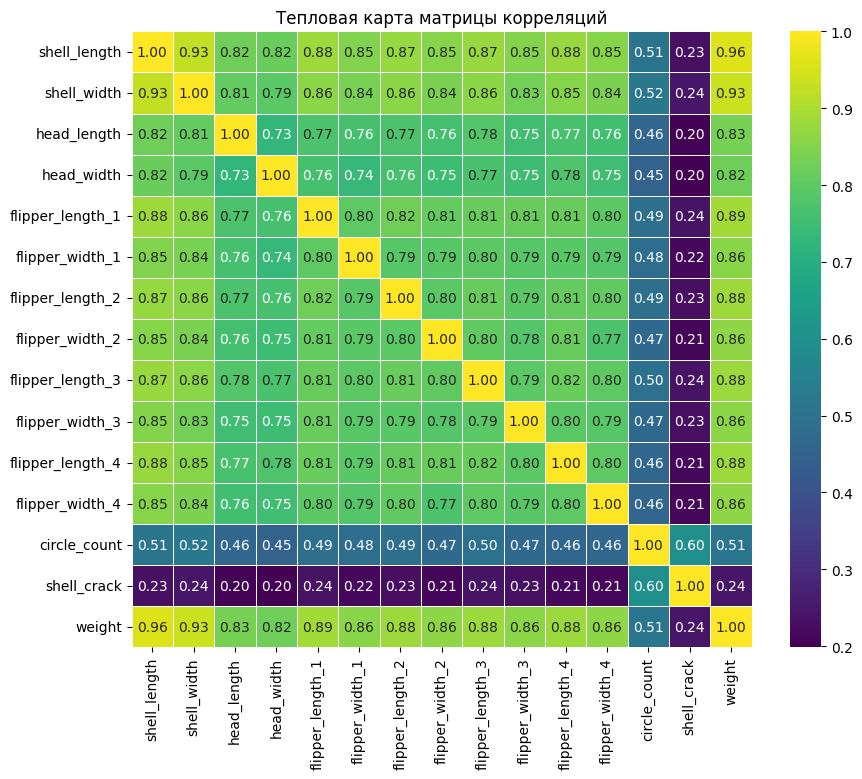

In [89]:
# Посчитаем матрицу корреляций
numeric_columns = df.columns
corr_matrix = df.phik_matrix(interval_cols=numeric_columns)

# Создаём тепловую  карту
plt.figure(figsize=(10, 8)) 

sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

# Показываем график с заголовком
plt.title('Тепловая карта матрицы корреляций')
plt.show()

Анализ:
- признаки shell_length и shell_width имеют высокое значение корреляции между собой: 0.93
- в то же время у них высокое значение корреляции с целевой переменной: shell_length - 0.96, shell_width - 0.93


Вывод:
- для избежания проблем с мультиколлинеарностью, при обучении моделей необходимо проводить регуляризацию (сглаживать значения весов)

#### Оценка масштаба данных

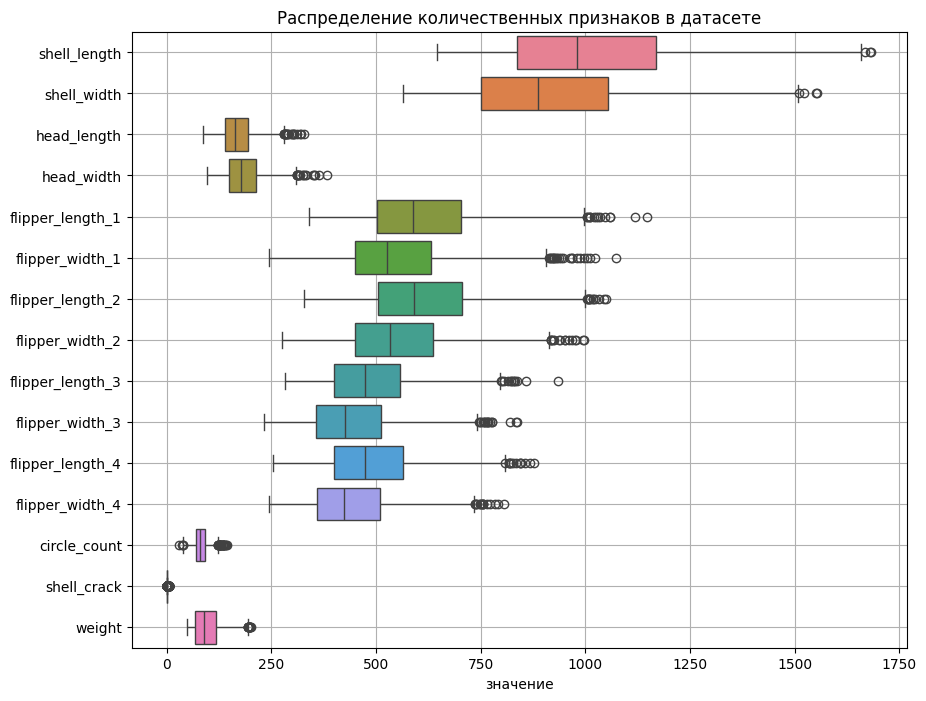

In [90]:
plt.figure(figsize=(10, 8))  
sns.boxplot(data=df, orient="h")
plt.title(f'Распределение количественных признаков в датасете')
plt.xlabel(f'значение')
plt.grid()

- данные имеют разный порядок величин. Имеет смысл сделать масштабирование. 

#### Итоговый датасет

In [91]:
df.info()

<class 'pandas.DataFrame'>
Index: 2483 entries, 8 to 7840
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2454 non-null   float32
 1   shell_width       2483 non-null   float32
 2   head_length       2448 non-null   float32
 3   head_width        2448 non-null   float32
 4   flipper_length_1  2483 non-null   float32
 5   flipper_width_1   2483 non-null   float32
 6   flipper_length_2  2483 non-null   float32
 7   flipper_width_2   2483 non-null   float32
 8   flipper_length_3  2454 non-null   float32
 9   flipper_width_3   2454 non-null   float32
 10  flipper_length_4  2454 non-null   float32
 11  flipper_width_4   2454 non-null   float32
 12  circle_count      2483 non-null   float32
 13  shell_crack       2483 non-null   float32
 14  weight            2483 non-null   float32
dtypes: float32(15)
memory usage: 164.9 KB


In [92]:
df.head()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
8,742.0,652.0,118.0,147.0,411.0,386.0,507.0,389.0,414.0,368.0,311.0,325.0,66.0,1.0,56.352001
11,1336.0,1318.0,207.0,248.0,845.0,704.0,661.0,768.0,587.0,686.0,661.0,585.0,111.0,5.0,154.074005
16,1010.0,926.0,216.0,156.0,562.0,488.0,529.0,432.0,467.0,434.0,553.0,463.0,76.0,0.0,87.695000
20,703.0,606.0,NaN,NaN,355.0,382.0,411.0,340.0,302.0,355.0,314.0,283.0,62.0,1.0,51.181999
21,982.0,940.0,187.0,157.0,518.0,557.0,545.0,463.0,497.0,511.0,541.0,479.0,103.0,0.0,92.707001


####  Промежуточный вывод 

- проведена нормализация данных для binomial_name к snake_case
- обнаружены пропуски в shell_crack. Их около 75%. Действуя в предположении, что пропуск окзачает отсутствие трещины, пропуски были заменены на 0. 
- удалены объекты с пропусками в целевой переменной weight (потери около 0.2%)
- остальные малочисленные пропуски оставлены без изменений. В будущем заменим на характерные значения
- удалены явные дубликаты. Потери при очистке: 11.5% 
- проведена фильтрация данных. В датасете остались только количественные признаки, характреризующие геометрию и внешний вид и массу черепахи
- проведена оптимизация размерностей данных
- в признаках "shell_length", "shell_width" обнаружены ошибки в единицах измерений, которые совершил волонтер. Ошибки исправлены
- в целевой переменной weight обнаружены нулевые значения, классифицированные как выбросы. Ошибки в данных были удалены. Потери при очистке малы и составили менее 0.2%
- результате анализа взаимосвязи признаков выявлено, что "shell_length" и "shell_width" сильнее прочих коррелирует между собой и с целевой переменной, корреляция составляет более 0.9. Для избежания проблемы мультиколлинератности, рекомендуется применить регуляризацию при обучении модели.
- поскольку признаки имеют различный масштаб, имеет смысл сделать масштабирование 

Итоговый датасет состоит из:
- 2483 объектов
- 14 признаков
- целевая переменная weight

## Предобработка данных

In [93]:
# исходные данные
X = df.drop(columns='weight')
y = df['weight']

### Разделение данных на выборки

In [94]:
# train-val 80% и test 20%
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

In [95]:
# train 60% и validate 20%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    shuffle=True,
    random_state=42
)

### Заполнение пропусков характерными значениями

In [96]:
# Меняем на характерные значения их train
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)
X_val = X_val.fillna(train_medians)

### Масштабирование

In [97]:
# Масштабирование
def scale_data(X_train, X_val, X_test, method='standard'):
    if method == 'standard':
        mean = X_train.mean()
        std = X_train.std()
        X_train_scaled = (X_train - mean) / std
        X_val_scaled = (X_val - mean) / std
        X_test_scaled = (X_test - mean) / std
    elif method == 'minmax':
        min_val = X_train.min()
        max_val = X_train.max()
        X_train_scaled = (X_train - min_val) / (max_val - min_val)
        X_val_scaled = (X_val - min_val) / (max_val - min_val)
        X_test_scaled = (X_test - min_val) / (max_val - min_val)
    else:
        raise ValueError("Неверный метод масштабирования. Используйте 'standard' или 'minmax'.")
    return X_train_scaled, X_val_scaled, X_test_scaled

In [98]:
# стандартизация
X_train_std, X_val_std, X_test_std = scale_data(X_train, X_val, X_test, method='standard')

In [99]:
# min-max масштабирование
X_train_mnmx, X_val_mnmx, X_test_mnmx = scale_data(X_train, X_val, X_test, method='minmax')

#### Промежуточный итог:
- проведено разделение датасета на train 60%, test 20%, validate 20%
- пропуски в данных заменены на характерные значения медиан из train
- подготовлено 3 группы датасетов: без масштабирования, стандартизованные, min-max масштабированные 

## Обучение моделей

### Обучение нескольких архитектур моделей

Варьируется: 
- набор отобранных признаков 
- масштаб признаков, установленными гиперпараметрами
- функции потерь
- разные значения гиперпараметра loss.

Модели для обучения:
- LinearRegression;
- Lasso (L1-регуляризация);
- Ridge (L2-регуляризация);
- SGDRegressor.

In [100]:
# датасет с моделями, данными, результатами
df_models_result = pd.DataFrame(columns=['model_name', 'dataset_info', 'MAE', 'RMSE', 'R2', 'MAPE'])
df_models_result = df_models_result.astype(
    {"model_name": str, "dataset_info": str, "MAE": float, "RMSE": float, "R2": float, "MAPE": float}
)
df_models_result

,model_name,dataset_info,MAE,RMSE,R2,MAPE


In [101]:
# метрики качества
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 3),
        'MAPE': round(mape, 2),
    }

In [102]:
def fit_train(model, X_train, y_train):
    # обучение на train
    model.fit(X_train, y_train)
    print(f"Модель: {model} обучена")
    return model

In [103]:
def get_df_result(model_name: str, dataset_info: str, metrics: dict):
    df_upd = pd.DataFrame(
        [[model_name, dataset_info, metrics['MAE'], metrics['RMSE'], metrics['R2'], metrics['MAPE']]], 
        columns=['model_name', 'dataset_info', 'MAE', 'RMSE', 'R2', 'MAPE'])
    return df_upd

In [104]:
# список моделей для обучения
models = [DummyRegressor, LinearRegression, Lasso, Ridge, SGDRegressor]

#### Различный набор признаков


***1. все признаки***

In [105]:
df_result = pd.DataFrame(columns=df_models_result.columns)

for model in models:
    model_learned = fit_train(model(), X_train, y_train)
    y_train_pred = model_learned.predict(X_train)
    metrics = calculate_metrics(y_train, y_train_pred)
    df_tmp = get_df_result(model_name=f'{repr(model_learned)}', dataset_info='default', metrics=metrics)
    df_result = pd.concat([df_result, df_tmp], ignore_index=True)

df_result

Модель: DummyRegressor() обучена
Модель: LinearRegression() обучена
Модель: Lasso() обучена
Модель: Ridge() обучена
Модель: SGDRegressor() обучена


,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,DummyRegressor(),default,28.45,34.71,0.0,0.32
1,LinearRegression(),default,3.69,4.85,0.98,0.04
2,Lasso(),default,3.69,4.85,0.98,0.04
3,Ridge(),default,3.69,4.85,0.98,0.04
4,SGDRegressor(),default,1466436689565832.5,1509016220951720.0,-1889696623829726544332324864.0,16134642665911.560547


In [106]:
df_models_result = pd.concat([df_models_result, df_result], ignore_index=True)

In [107]:
df_models_result

,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,DummyRegressor(),default,28.45,34.71,0.0,0.32
1,LinearRegression(),default,3.69,4.85,0.98,0.04
2,Lasso(),default,3.69,4.85,0.98,0.04
3,Ridge(),default,3.69,4.85,0.98,0.04
4,SGDRegressor(),default,1466436689565832.5,1509016220951720.0,-1889696623829726544332324864.0,16134642665911.560547


**2. Объединение коррелирующих признаков**
- длина и ширина панциря черепахи сильно коррелирует между собой 
- объединим эти признаки в новый: площать соответствующей конечности

In [108]:
X_train[['shell_length', 'shell_width']].corr()

,shell_length,shell_width
shell_length,1.000000,0.948401
shell_width,0.948401,1.000000


In [109]:
X_train_comb = X_train.copy()

In [110]:
X_train_comb['shell_area'] = X_train_comb['shell_length'] * X_train_comb['shell_width']
X_train_comb = X_train_comb.drop(['shell_length', 'shell_width'], axis=1)
X_train_comb.head()

,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,shell_area
480,164.0,248.0,726.0,721.0,731.0,659.0,642.0,644.0,616.0,536.0,128.0,0.0,1503180.0
2250,175.0,204.0,623.0,555.0,604.0,526.0,524.0,417.0,487.0,482.0,73.0,0.0,961832.0
3837,167.0,224.0,672.0,516.0,615.0,593.0,537.0,394.0,547.0,467.0,100.0,0.0,948534.0
2000,126.0,113.0,441.0,383.0,444.0,329.0,358.0,327.0,315.0,304.0,69.0,0.0,495391.0
4195,216.0,252.0,918.0,806.0,717.0,896.0,677.0,583.0,675.0,683.0,134.0,0.0,1616924.0


In [111]:
df_result = pd.DataFrame(columns=df_models_result.columns)

for model in models:
    model_learned = fit_train(model(), X_train_comb, y_train)
    y_train_pred = model_learned.predict(X_train_comb)
    metrics = calculate_metrics(y_train, y_train_pred)
    df_tmp = get_df_result(model_name=f'{repr(model_learned)}', dataset_info='comb_feat', metrics=metrics)
    df_result = pd.concat([df_result, df_tmp], ignore_index=True)

df_result

Модель: DummyRegressor() обучена
Модель: LinearRegression() обучена
Модель: Lasso() обучена
Модель: Ridge() обучена
Модель: SGDRegressor() обучена


/Users/arseniy/study/practicum/data_science/practicum_ds/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.130807675084558e-12.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,DummyRegressor(),comb_feat,28.45,34.71,0.0,0.32
1,LinearRegression(),comb_feat,3.26,4.46,0.983,0.03
2,Lasso(),comb_feat,3.16,4.27,0.985,0.03
3,Ridge(),comb_feat,3.16,4.27,0.985,0.03
4,SGDRegressor(),comb_feat,607848951543760289792.0,665394977017933201408.0,-367420434994116745733109677532878209024.0,6227663672460360704.0


In [112]:
df_models_result

,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,DummyRegressor(),default,28.45,34.71,0.0,0.32
1,LinearRegression(),default,3.69,4.85,0.98,0.04
2,Lasso(),default,3.69,4.85,0.98,0.04
3,Ridge(),default,3.69,4.85,0.98,0.04
4,SGDRegressor(),default,1466436689565832.5,1509016220951720.0,-1889696623829726544332324864.0,16134642665911.560547


Анализ:
- Ключавые метрики улучшились для LinearRegression, Lasso, Ridge: MAE снизилось на 14%, RMSE снизилось на 12%, R2 повысилось на 0.5%, MAPE уменьшилось на 25%

Вывод:
- обучение на преобразованных данных однозначно стоит исследовать на validate, поскольку метрики на train существенно улучшились 

In [113]:
df_models_result = pd.concat([df_models_result, df_result], ignore_index=True)

In [114]:
df_models_result

,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,DummyRegressor(),default,28.45,34.71,0.0,0.32
1,LinearRegression(),default,3.69,4.85,0.98,0.04
2,Lasso(),default,3.69,4.85,0.98,0.04
3,Ridge(),default,3.69,4.85,0.98,0.04
4,SGDRegressor(),default,1466436689565832.5,1509016220951720.0,-1889696623829726544332324864.0,16134642665911.560547
5,DummyRegressor(),comb_feat,28.45,34.71,0.0,0.32
6,LinearRegression(),comb_feat,3.26,4.46,0.983,0.03
7,Lasso(),comb_feat,3.16,4.27,0.985,0.03
8,Ridge(),comb_feat,3.16,4.27,0.985,0.03
9,SGDRegressor(),comb_feat,607848951543760289792.0,665394977017933201408.0,-367420434994116745733109677532878209024.0,6227663672460360704.0


#### Различный масштаб данных

***1. Стандартизованные данные***

In [115]:
df_result = pd.DataFrame(columns=df_models_result.columns)

for model in models:
    model_learned = fit_train(model(), X_train_std, y_train)
    y_train_pred = model_learned.predict(X_train_std)
    metrics = calculate_metrics(y_train, y_train_pred)
    df_tmp = get_df_result(model_name=f'{repr(model_learned)}', dataset_info='std', metrics=metrics)
    df_result = pd.concat([df_result, df_tmp], ignore_index=True)
    
df_result

Модель: DummyRegressor() обучена
Модель: LinearRegression() обучена
Модель: Lasso() обучена
Модель: Ridge() обучена
Модель: SGDRegressor() обучена


,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,DummyRegressor(),std,28.45,34.71,0.0,0.32
1,LinearRegression(),std,3.69,4.85,0.98,0.04
2,Lasso(),std,3.65,4.99,0.979,0.04
3,Ridge(),std,3.69,4.85,0.98,0.04
4,SGDRegressor(),std,3.76,4.87,0.98,0.04


In [116]:
df_models_result

,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,DummyRegressor(),default,28.45,34.71,0.0,0.32
1,LinearRegression(),default,3.69,4.85,0.98,0.04
2,Lasso(),default,3.69,4.85,0.98,0.04
3,Ridge(),default,3.69,4.85,0.98,0.04
4,SGDRegressor(),default,1466436689565832.5,1509016220951720.0,-1889696623829726544332324864.0,16134642665911.560547
5,DummyRegressor(),comb_feat,28.45,34.71,0.0,0.32
6,LinearRegression(),comb_feat,3.26,4.46,0.983,0.03
7,Lasso(),comb_feat,3.16,4.27,0.985,0.03
8,Ridge(),comb_feat,3.16,4.27,0.985,0.03
9,SGDRegressor(),comb_feat,607848951543760289792.0,665394977017933201408.0,-367420434994116745733109677532878209024.0,6227663672460360704.0


**Анализ:**

При стандартизации:
- SGDRegressor теперь лучше DummyModel по метрикам.
- ключевая метрика метрика MAE уменьшилась для моделей: Lasso меньше на 1%, SGDRegressor теперь менее 5. Для остальных моделей изменений нет.
- метрика R2 практически не изменяется

**Вывод:**

- Примененная стандартизация улучшает ключевые метрики работы моделей. Рекомендуются ее применить

In [117]:
df_models_result = pd.concat([df_models_result, df_result], ignore_index=True)
df_models_result

,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,DummyRegressor(),default,28.45,34.71,0.0,0.32
1,LinearRegression(),default,3.69,4.85,0.98,0.04
2,Lasso(),default,3.69,4.85,0.98,0.04
3,Ridge(),default,3.69,4.85,0.98,0.04
4,SGDRegressor(),default,1466436689565832.5,1509016220951720.0,-1889696623829726544332324864.0,16134642665911.560547
5,DummyRegressor(),comb_feat,28.45,34.71,0.0,0.32
6,LinearRegression(),comb_feat,3.26,4.46,0.983,0.03
7,Lasso(),comb_feat,3.16,4.27,0.985,0.03
8,Ridge(),comb_feat,3.16,4.27,0.985,0.03
9,SGDRegressor(),comb_feat,607848951543760289792.0,665394977017933201408.0,-367420434994116745733109677532878209024.0,6227663672460360704.0


***2. Min-max масштабирование***

In [118]:
df_result = pd.DataFrame(columns=df_models_result.columns)

for model in models:
    model_learned = fit_train(model(), X_train_mnmx, y_train)
    y_train_pred = model_learned.predict(X_train_mnmx)
    metrics = calculate_metrics(y_train, y_train_pred)
    df_tmp = get_df_result(model_name=f'{repr(model_learned)}', dataset_info='min-max', metrics=metrics)

    df_result = pd.concat([df_result, df_tmp], ignore_index=True)
    
df_result

Модель: DummyRegressor() обучена
Модель: LinearRegression() обучена
Модель: Lasso() обучена
Модель: Ridge() обучена
Модель: SGDRegressor() обучена


,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,DummyRegressor(),min-max,28.45,34.71,0.0,0.32
1,LinearRegression(),min-max,3.69,4.85,0.98,0.04
2,Lasso(),min-max,5.47,7.79,0.95,0.06
3,Ridge(),min-max,3.7,4.86,0.98,0.04
4,SGDRegressor(),min-max,3.87,5.05,0.979,0.04


In [119]:
df_models_result

,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,DummyRegressor(),default,28.45,34.71,0.0,0.32
1,LinearRegression(),default,3.69,4.85,0.98,0.04
2,Lasso(),default,3.69,4.85,0.98,0.04
3,Ridge(),default,3.69,4.85,0.98,0.04
4,SGDRegressor(),default,1466436689565832.5,1509016220951720.0,-1889696623829726544332324864.0,16134642665911.560547
5,DummyRegressor(),comb_feat,28.45,34.71,0.0,0.32
6,LinearRegression(),comb_feat,3.26,4.46,0.983,0.03
7,Lasso(),comb_feat,3.16,4.27,0.985,0.03
8,Ridge(),comb_feat,3.16,4.27,0.985,0.03
9,SGDRegressor(),comb_feat,607848951543760289792.0,665394977017933201408.0,-367420434994116745733109677532878209024.0,6227663672460360704.0


**Анализ:**

При min-max масшабировании:
- SGDRegressor теперь лучше DummyModel по метрикам.
- ключевая метрика метрика MAE уменьшаяется для LinearRegression на 0.5% и приводит SGDRegressor в диапазон <5. Для всех остальных моделей: Lasso, Ridge  метрика MAE растет и принимает значения в диапазоне: 4.21 - 6.16
- метрика R2 остается на прежнем уровне для Ridge и LinearRegression. Для Lasso метрика падает на 5%

**Вывод:**

- Примененное масштабирование улучшает ключевые метрики для SGDRegressor и LinearRegression. Для остальных моделей положительного эффекта нет. Такой вид масштабирования проигрывает стандартизации, поэтому его применять не рекомендуется 

#### Различные loss функции

In [120]:
# Ridge с различными alpha
# берем стандартизованную выборку

alphas = [0.01, 0.1, 1, 10, 50, 100]

df_result = pd.DataFrame(columns=df_models_result.columns)


for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    model_learned = fit_train(ridge, X_train_std, y_train)
    y_train_pred = model_learned.predict(X_train_std)
    metrics = calculate_metrics(y_train, y_train_pred)
    df_tmp = get_df_result(model_name=f'{repr(model_learned)}', dataset_info='std', metrics=metrics)

    df_result = pd.concat([df_result, df_tmp], ignore_index=True)

    
df_result

Модель: Ridge(alpha=0.01) обучена
Модель: Ridge(alpha=0.1) обучена
Модель: Ridge(alpha=1) обучена
Модель: Ridge(alpha=10) обучена
Модель: Ridge(alpha=50) обучена
Модель: Ridge(alpha=100) обучена


,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,Ridge(alpha=0.01),std,3.69,4.85,0.98,0.04
1,Ridge(alpha=0.1),std,3.69,4.85,0.98,0.04
2,Ridge(alpha=1),std,3.69,4.85,0.98,0.04
3,Ridge(alpha=10),std,3.7,4.85,0.98,0.04
4,Ridge(alpha=50),std,3.74,4.91,0.98,0.04
5,Ridge(alpha=100),std,3.79,4.98,0.979,0.04


In [121]:
df_models_result

,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,DummyRegressor(),default,28.45,34.71,0.0,0.32
1,LinearRegression(),default,3.69,4.85,0.98,0.04
2,Lasso(),default,3.69,4.85,0.98,0.04
3,Ridge(),default,3.69,4.85,0.98,0.04
4,SGDRegressor(),default,1466436689565832.5,1509016220951720.0,-1889696623829726544332324864.0,16134642665911.560547
5,DummyRegressor(),comb_feat,28.45,34.71,0.0,0.32
6,LinearRegression(),comb_feat,3.26,4.46,0.983,0.03
7,Lasso(),comb_feat,3.16,4.27,0.985,0.03
8,Ridge(),comb_feat,3.16,4.27,0.985,0.03
9,SGDRegressor(),comb_feat,607848951543760289792.0,665394977017933201408.0,-367420434994116745733109677532878209024.0,6227663672460360704.0


**Анализ:**

- при alpha от [0.01, 0.1, 1] метрики MAE = 3.69 и R2 = 0.98
- при alpha > 1 метрики начинают ухудшаться: MAE растет, а R2 падает

**Вывод:**

- оставляем дефолтное значение alpha = 1 (в итоговом датасете уже есть)

In [122]:
# Lasso с различными alpha
# берем стандартизованную выборку
alphas = [0.01, 0.1, 1, 10, 50, 100]

df_result = pd.DataFrame(columns=df_models_result.columns)

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    model_learned = fit_train(lasso, X_train_std, y_train)
    y_train_pred = model_learned.predict(X_train_std)
    metrics = calculate_metrics(y_train, y_train_pred)
    df_tmp = get_df_result(model_name=f'{repr(model_learned)}', dataset_info='std', metrics=metrics)

    df_result = pd.concat([df_result, df_tmp], ignore_index=True)

    
df_result

Модель: Lasso(alpha=0.01) обучена
Модель: Lasso(alpha=0.1) обучена
Модель: Lasso(alpha=1) обучена
Модель: Lasso(alpha=10) обучена
Модель: Lasso(alpha=50) обучена
Модель: Lasso(alpha=100) обучена


,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,Lasso(alpha=0.01),std,3.69,4.85,0.98,0.04
1,Lasso(alpha=0.1),std,3.68,4.85,0.98,0.04
2,Lasso(alpha=1),std,3.65,4.99,0.979,0.04
3,Lasso(alpha=10),std,9.1,11.79,0.885,0.1
4,Lasso(alpha=50),std,28.45,34.71,0.0,0.32
5,Lasso(alpha=100),std,28.45,34.71,0.0,0.32


**Анализ:**

- при alpha = 1 метрика MAE: 3.65 принимает минимальное значение
- при alpha < 1 MAE и R2 меняются не существенно (менее 1%)
- при alpha > 1  для модели Lasso метрики начинают резко ухудшаться

**Вывод:**

- оставляем дефолтное значение alpha = 1 (уже есть в датасете)

In [124]:
# SGDRegressor с различными loss
# берем стандартизованную выборку

loss_funcs = ['squared_error', 'huber']

df_result = pd.DataFrame(columns=df_models_result.columns)

for loss in loss_funcs:
    sgdr = SGDRegressor(
        learning_rate='constant',
        eta0=0.01,
        max_iter=1000,
        loss=loss,
        tol=1e-3,                  
        random_state=42           
    )
    model_learned = fit_train(sgdr, X_train_std, y_train)
    y_train_pred = model_learned.predict(X_train_std)
    metrics = calculate_metrics(y_train, y_train_pred)
    df_tmp = get_df_result(model_name=f'{repr(model_learned)}', dataset_info='std', metrics=metrics)

    df_result = pd.concat([df_result, df_tmp], ignore_index=True)

    
df_result

Модель: SGDRegressor(learning_rate='constant', random_state=42) обучена
Модель: SGDRegressor(learning_rate='constant', loss='huber', random_state=42) обучена


,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,"SGDRegressor(learning_rate='constant', random_...",std,4.27,5.35,0.976,0.05
1,"SGDRegressor(learning_rate='constant', loss='h...",std,3.86,5.23,0.977,0.04


**Анализ:**

- для squared_loss 'MAE': 4.27, 'RMSE': 5.35, 'R2': 0.05, MAPE: 0.05
- для huber loss: 'MAE': 3.85, 'RMSE': 5.24	, 'R2': 0.977, MAPE: 0.04
- по всем метрикам huber лучше, чем squared_loss

**Вывод:**

- рекомендуется использовать huber loss для SGDRegressor

In [125]:
df_result = df_result.iloc[1, :]
df_models_result = pd.concat([df_models_result, df_result.to_frame().T], ignore_index=True)
df_models_result

,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,DummyRegressor(),default,28.45,34.71,0.0,0.32
1,LinearRegression(),default,3.69,4.85,0.98,0.04
2,Lasso(),default,3.69,4.85,0.98,0.04
3,Ridge(),default,3.69,4.85,0.98,0.04
4,SGDRegressor(),default,1466436689565832.5,1509016220951720.0,-1889696623829726544332324864.0,16134642665911.560547
5,DummyRegressor(),comb_feat,28.45,34.71,0.0,0.32
6,LinearRegression(),comb_feat,3.26,4.46,0.983,0.03
7,Lasso(),comb_feat,3.16,4.27,0.985,0.03
8,Ridge(),comb_feat,3.16,4.27,0.985,0.03
9,SGDRegressor(),comb_feat,607848951543760289792.0,665394977017933201408.0,-367420434994116745733109677532878209024.0,6227663672460360704.0


In [126]:
# SGDRegressor с различными eta0
eta_list = [0.001, 0.01, 0.1, 1]

df_result = pd.DataFrame(columns=df_models_result.columns)

for eta in eta_list:
    sgdr = SGDRegressor(
        learning_rate='constant',
        eta0=eta,
        max_iter=1000,
        loss=loss,
        tol=1e-3,                  
        random_state=42           
    )
    model_learned = fit_train(sgdr, X_train_std, y_train)
    y_train_pred = model_learned.predict(X_train_std)
    metrics = calculate_metrics(y_train, y_train_pred)
    df_tmp = get_df_result(model_name=f'{repr(model_learned)}', dataset_info='std', metrics=metrics)

    df_result = pd.concat([df_result, df_tmp], ignore_index=True)
df_result

Модель: SGDRegressor(eta0=0.001, learning_rate='constant', loss='huber',
             random_state=42) обучена
Модель: SGDRegressor(learning_rate='constant', loss='huber', random_state=42) обучена
Модель: SGDRegressor(eta0=0.1, learning_rate='constant', loss='huber', random_state=42) обучена
Модель: SGDRegressor(eta0=1, learning_rate='constant', loss='huber', random_state=42) обучена


,model_name,dataset_info,MAE,RMSE,R2,MAPE
0,"SGDRegressor(eta0=0.001, learning_rate='consta...",std,4.14,5.72,0.973,0.04
1,"SGDRegressor(learning_rate='constant', loss='h...",std,3.86,5.23,0.977,0.04
2,"SGDRegressor(eta0=0.1, learning_rate='constant...",std,3.63,4.93,0.98,0.04
3,"SGDRegressor(eta0=1, learning_rate='constant',...",std,4.05,5.92,0.971,0.04


**Анализ:**

- наилучшее значение метрик при eta0=0.1: 'MAE': 3.62, 'RMSE': 4.93, 'R2': 0.98, MAPE: 0.04

**Вывод:**

- выбираем значение eta0=0.1

In [127]:
df_result.loc[2, :]

model_name      SGDRegressor(eta0=0.1, learning_rate='constant...
dataset_info                                                  std
MAE                                                          3.63
RMSE                                                         4.93
R2                                                           0.98
MAPE                                                         0.04
Name: 2, dtype: object

In [128]:
df_models_result = pd.concat([df_models_result, df_result.loc[[2], :]], ignore_index=True)

#### Итоговая таблица 

In [129]:
df_models_result.sort_values(by='MAE')

,model_name,dataset_info,MAE,RMSE,R2,MAPE
8,Ridge(),comb_feat,3.16,4.27,0.985,0.03
7,Lasso(),comb_feat,3.16,4.27,0.985,0.03
6,LinearRegression(),comb_feat,3.26,4.46,0.983,0.03
16,"SGDRegressor(eta0=0.1, learning_rate='constant...",std,3.63,4.93,0.98,0.04
12,Lasso(),std,3.65,4.99,0.979,0.04
2,Lasso(),default,3.69,4.85,0.98,0.04
1,LinearRegression(),default,3.69,4.85,0.98,0.04
11,LinearRegression(),std,3.69,4.85,0.98,0.04
13,Ridge(),std,3.69,4.85,0.98,0.04
3,Ridge(),default,3.69,4.85,0.98,0.04


**Вывод:**
- за счет стандартизации удалось увеличить точность предсказания моделей
- подбор шага обучения для SGDRegressor положительно сказался на итоговом качестве модели. Рекомендуется проверить на validate eta0=0.1 помимо дефолтного зачения
- выбор huber loss для SGDRegressor также улучшил метрики модели. Рекомендуется проверить на validate функцию huber loss
- модели существенно улучшили результат на датасете с объединением высоко коррелированных метрик. Рекомендуется проверить на validate признак shell_area = shell_length * shell_width


## Сравнение моделей на валидационной выборке

In [130]:
def validate_metrics(model_trained, X_val, y_val):
    """Для обученной модели выводит метрики, рассчитанные на validate"""
    # предсказание на validate
    y_pred = model_trained.predict(X_val)
    # метрики
    metrics = calculate_metrics(y_val, y_pred)
    return metrics

In [131]:
# интересующие модели
sgdr = SGDRegressor(
        learning_rate='constant',
        eta0=0.01,
        max_iter=1000,
        tol=1e-3,                  
        random_state=42           
)

sgdr_eta_mod = SGDRegressor(
        learning_rate='constant',
        eta0=0.1,
        max_iter=1000,
        tol=1e-3,                  
        random_state=42           
)

sgdr_huber = SGDRegressor(
        learning_rate='constant',
        eta0=0.01,
        max_iter=1000,
        loss='huber',
        tol=1e-3,                  
        random_state=42           
)

sgdr_eta_mod_huber = SGDRegressor(
        learning_rate='constant',
        eta0=0.1,
        max_iter=1000,
        loss='huber',
        tol=1e-3,                  
        random_state=42           
)

lasso_model = Lasso()
lr_model = LinearRegression()
ridge_model = Ridge()

models = [sgdr, sgdr_eta_mod, sgdr_huber, sgdr_eta_mod_huber, lasso_model, lr_model, ridge_model]
model_names = ['sgdr', 'sgdr_eta_mod', 'sgdr_huber', 'sgdr_eta_mod_huber', 'lasso_model', 'lr_model', 'ridge_model']

In [132]:
# обучаем на train
# стандратизованная выборка

for model in models:
    model.fit(X_train_std, y_train)

In [133]:
# сравнение на validate
df_result = pd.DataFrame(columns=df_models_result.columns)

for model, name in zip(models, model_names):
    metrics = validate_metrics(model, X_val_std, y_val)
    df_tmp = get_df_result(model_name=name, dataset_info='val_std', metrics=metrics)

    df_result = pd.concat([df_result, df_tmp], ignore_index=True)

df_result.sort_values(by=['MAE', 'R2'], ascending=[True, False])

,model_name,dataset_info,MAE,RMSE,R2,MAPE
5,lr_model,val_std,3.86,5.05,0.981,0.04
6,ridge_model,val_std,3.86,5.05,0.981,0.04
3,sgdr_eta_mod_huber,val_std,3.86,5.18,0.98,0.04
4,lasso_model,val_std,3.93,5.27,0.979,0.04
2,sgdr_huber,val_std,4.08,5.47,0.977,0.04
0,sgdr,val_std,4.28,5.47,0.977,0.05
1,sgdr_eta_mod,val_std,134524607189.669998,162538714676.440002,-20154019168489979904.0,1623252939.3


- лучшая модель: **SGDRegressor** с подобранным шагом обучения eta0=0.1 и huber loss 
- метрики лучшей модели: 
    - MAE 3.84	
    - RMSE 5.2
    - R2 0.979	
    - MAPE 0.04

**2. стандратизованная выборка c объединением признаков**

In [134]:
def comb_shell_feat(X):
    X['shell_area'] = X['shell_length'] * X['shell_width']
    X = X.drop(['shell_length', 'shell_width'], axis=1)
    return X
    
X_train_comb = X_train.copy()
X_train_comb = comb_shell_feat(X_train_comb)

X_val_comb = X_val.copy()
X_val_comb = comb_shell_feat(X_val_comb)

X_test_comb = X_test.copy()
X_test_comb = comb_shell_feat(X_test_comb)


X_train_comb_std, X_val_comb_std, X_test_comb_std = scale_data(
    X_train_comb, X_val_comb, X_test_comb, method='standard'
)

In [135]:
# обучаем на train
for model in models:
    model.fit(X_train_comb_std, y_train)
    

In [136]:
df_result = pd.DataFrame(columns=df_models_result.columns)

for model, name in zip(models, model_names):
    metrics = validate_metrics(model, X_val_comb_std, y_val)
    df_tmp = get_df_result(model_name=name, dataset_info='val_std', metrics=metrics)

    df_result = pd.concat([df_result, df_tmp], ignore_index=True)

df_result.sort_values(by=['MAE', 'R2'], ascending=[True, False])

,model_name,dataset_info,MAE,RMSE,R2,MAPE
5,lr_model,val_std,3.32,4.42,0.985,0.03
6,ridge_model,val_std,3.32,4.42,0.985,0.03
3,sgdr_eta_mod_huber,val_std,3.35,4.52,0.984,0.03
4,lasso_model,val_std,3.39,4.59,0.984,0.04
2,sgdr_huber,val_std,3.71,4.96,0.981,0.04
0,sgdr,val_std,3.93,5.17,0.98,0.04
1,sgdr_eta_mod,val_std,60905872705.059998,72408631461.850006,-3999711840256039424.0,735662908.92


- лучшие модели: **LinearRegression**, **Ridge**
- метрики лучших моделей: 
    - MAE 3.3
    - RMSE 4.42
    - R2 9.85
    - MAPE 0.03
    
Отметим, что объединение по высоко коррелированным признаков + стандартизация данных дает наилучше метрики на validate

Вывод:
- выборку для обучения необходимо стандартизовать, высоко коррелированные признаки лучше объединить. Так можно добиться наилучших метрик качетсва на validate
- лучшие модели: LinearRegression, Ridge (одинаковые показатели по MAE, RMSE, R2)
- результат базовой модели DummyModel сильно улучшен: DummyRegressor MAE = 28.6; Ridge  MAE = 3.3
- для дальнейших проверок принято решение искользовать модель Ridge. При равенстве по метрикам с LinearRegression она более устойчива к проблеме переобучения за счет регуляризации


## Проверка лучшей модели на тестовой выборке

#### Проверка лучшей модели на test

In [83]:
# проверка лучше модели на test
y_test_pred_ridge = ridge_model.predict(X_test_comb_std)

In [84]:
# метрики на test
calculate_metrics(y_test, y_test_pred_ridge)

{'MAE': 3.41, 'RMSE': 4.66, 'R2': 0.982, 'MAPE': 0.03}

- метрики на test мало отличаются от train и validate и удовлетворяют требованиям заказчика

#### Проверка на переобучение

In [85]:
# метрики на val
y_val_pred_ridge = ridge_model.predict(X_val_comb_std)
calculate_metrics(y_val, y_val_pred_ridge)

{'MAE': 3.32, 'RMSE': 4.42, 'R2': 0.985, 'MAPE': 0.03}

In [86]:
# метрики на train
y_train_pred_ridge = ridge_model.predict(X_train_comb_std)
calculate_metrics(y_train, y_train_pred_ridge)

{'MAE': 3.16, 'RMSE': 4.27, 'R2': 0.985, 'MAPE': 0.03}

**Вывод:**
- модель показывает высокое качество на test, train и val. Следовательно, она применима к данным для получения предсказаний. Признаков переобучения нет

### Вывод

- разработанная модель Ridge с настройками по умолчанию, применяемая к стандартизованной выборке с объединением высоко коррелированных признаков, удовлетворяет требованиям заказчика по ключевым метрикам: MAE = 3.41 < 5, R2 = 0.982 > 0.97, MAPE = 3%
- Следовательно, ее можно рекомендовать к использованию

## Оценка важности признаков

1. Оцениваем важность признаков по абсолютным значениям весов лучшей модели.

In [137]:
coef_abs = abs(ridge_model.coef_)
indices = np.arange(len(coef_abs))


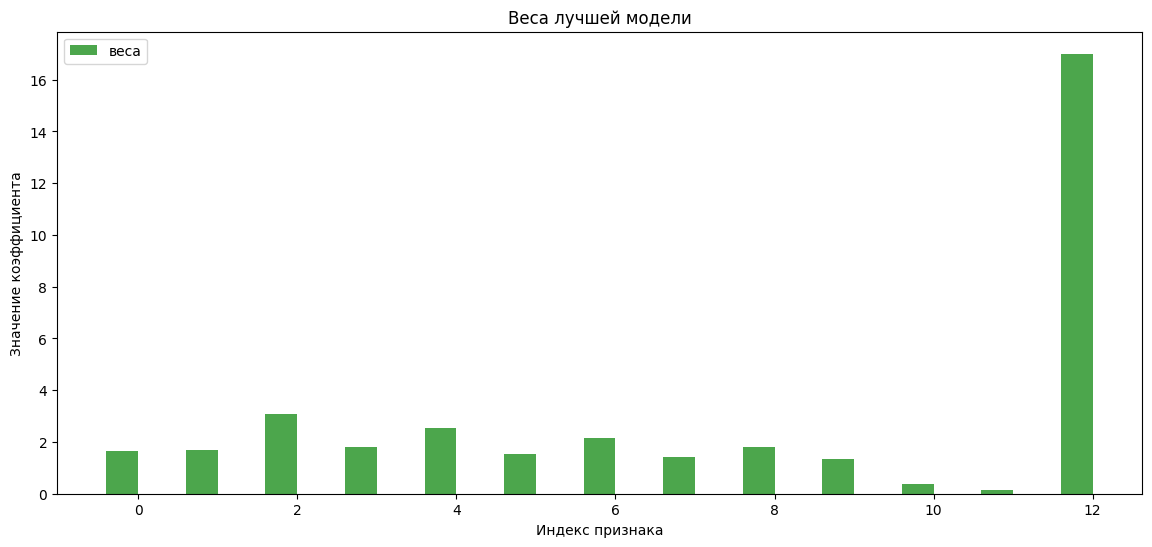

In [138]:
plt.figure(figsize=(14, 6))  # Размер графика
width = 0.4  # Ширина столбцов на графике

plt.bar(indices - width/2, coef_abs, width=width, label='веса', color='green', alpha=0.7)

plt.xlabel('Индекс признака')  # Подпись оси X
plt.ylabel('Значение коэффициента')  # Подпись оси Y
plt.title('Веса лучшей модели')  # Заголовок графика
plt.legend()  # Отображаем легенду
plt.show()  # Показываем график

In [139]:
# фильтруем индексы по важности
sorted_idx = np.argsort(-coef_abs)
sorted_idx

array([12,  2,  4,  6,  3,  8,  1,  0,  5,  7,  9, 10, 11])

In [140]:
# берем топ-5
sorted_idx = sorted_idx[:5]
sorted_idx

array([12,  2,  4,  6,  3])

In [141]:
# каким признакам соответствуют
important_features = X_val_comb_std.iloc[:, sorted_idx].columns
important_features

Index(['shell_area', 'flipper_length_1', 'flipper_length_2',
       'flipper_length_3', 'flipper_width_1'],
      dtype='str')

**Вывод:**
- самые важые признаки по мнению модели: 'shell_area', 'flipper_length_1', 'flipper_length_2', 'flipper_length_3', 'flipper_width_1'

In [142]:
df_upd = df.copy()
df_upd['shell_area'] = df_upd['shell_length'] * df_upd['shell_width']
df_upd = df_upd.drop(['shell_length', 'shell_width'], axis=1)

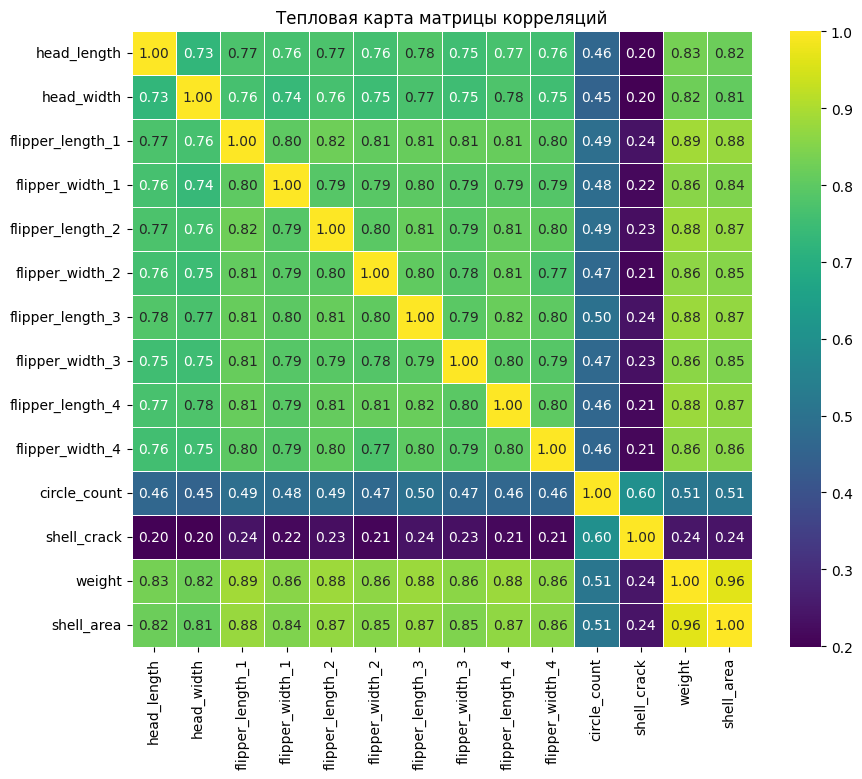

In [143]:
# Посчитаем матрицу корреляций
numeric_columns = df_upd.columns
corr_matrix = df_upd.phik_matrix(interval_cols=numeric_columns)

# Создаём тепловую  карту
plt.figure(figsize=(10, 8)) 

sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

# Показываем график с заголовком
plt.title('Тепловая карта матрицы корреляций')
plt.show()

In [144]:
print("Корреляция переменных с целевой переменной 'weight':")
print(corr_matrix['weight'].sort_values(ascending=False).head(7))


Корреляция переменных с целевой переменной 'weight':
weight              1.000000
shell_area          0.963806
flipper_length_1    0.888012
flipper_length_2    0.882113
flipper_length_4    0.880172
flipper_length_3    0.879494
flipper_width_4     0.863711
Name: weight, dtype: float64


- самые важные по мнению модели признаки максимально коррелируют с искомой величиной. 

#### Вывод:
- в ходе анализа абсолютных значений весов модели были определены наиболее важные признаки: 'shell_area', 'flipper_length_2', 'flipper_length_1', 'flipper_width_1', 'flipper_length_4'
- результат совпал с ожидаемым и легко интерпретируем: большой вес признака в модели отражает высокую корреляцию с целевой переменной

## Функция для прогнозирования веса черепахи

In [145]:
best_model = ridge_model

In [146]:
def predict_weight(x_params: np.ndarray, model_weights: np.ndarray, model_bias: float) -> float:
    """
    Прогнозирует массу черепахи
    
    Args:
        x_params (np.ndarray): вектор параметров
        model_weights (np.ndarray): вектор весов модели, размерность совпадает с x_params
        model_bias (float): линейный сдвиг модели

    Returns:
        (float): масса черепахи, кг
    
    """
    return x_params @ model_weights + model_bias


In [147]:
# пример использования
# 1. Параметры лучшей модели:
model_weights = best_model.coef_
model_bias = best_model.intercept_

In [148]:
# 2. Стандартизованный вектор измерений с объединенными признаками shell_area = shell_length * shell_width 
# (значения строго в заданном порядке)
x_params = X_test_comb_std.iloc[0, :]
x_params

head_length        -1.269558
head_width         -1.108271
flipper_length_1   -1.513327
flipper_width_1    -1.716348
flipper_length_2   -1.603621
flipper_width_2    -1.445304
flipper_length_3   -1.434280
flipper_width_3    -1.344143
flipper_length_4   -0.984744
flipper_width_4    -0.626134
circle_count       -1.171113
shell_crack        -0.453158
shell_area         -1.156858
Name: 4962, dtype: float32

In [149]:
# 3. Предсказание массы черепахи
weight = predict_weight(x_params=x_params, model_weights=model_weights, model_bias=model_bias)
weight

np.float32(49.424583)

In [150]:
# 4. Проверка работы функции через предсказание модели
best_model.predict([x_params])

/Users/arseniy/study/practicum/data_science/practicum_ds/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


array([49.424583], dtype=float32)

- результаты совпали, функция работает корректно

## Общие выводы и рекомендации по дальнейшей работе

Вывод:
- решалась задача линейной регресии для прогнозирования массы черепахи по измерениям с аппаратуры камеры TurtleCV
- была проведена обработка данных: устранены дубликаты 11.4%, проведена нормализация строковых данных, отсутствующие значения в shell_crack заменены на 0, пропуски в остальных столбцах заменены на характерные значения по выборкам
- для избежения проблем мультиколлинеарности рекомендовано объединить признаки: shell_area = shell_length * shell_width 
- из датасет устранены бесполезные для обучения моделей данные: индексы, характеристики сбора данных о черепахах
- после первичной обработки данных выявлено, что датасет содердит данные разного масштаба
- исследование влияния масштабирования показало, что для обучения линейных моделей критически важно применять стандартизацию. Это сущственно повышает предсказательную спопобность моделей (улучшаются ключевые метрики MAE и R2).
- объединение признаков с высокой корреляцией shell_area = shell_length * shell_width повысило качество предсказаний моделей
- сравнительный анализ моделей LinearRegression, Ridge, Lasso, SGDRegressor показал, что лучший выбор для настоящей задачи: Ridge(alpha=1) модель с L2 регуяризацией. Эта модель показала наилучший результат по ключевым метрикам: {'MAE': 3.41, 'RMSE': 4.66, 'R2': 0.982, 'MAPE': 0.03}. Значения метрик удовлетворяют требованиям заказчика. Эту модель рекомендуется использовать.
- Наиболее важные признаки для модели: 'shell_area', 'flipper_length_2', 'flipper_length_1', 'flipper_width_1', 'flipper_length_4'. Они сильнее остальных коррелируют и целевой переменной.
- реализована функция predict_weight, прогнозирующая массу черепахи. Работа функции проверена с помощью лучшей отобранно модели
- Перспективы исследований: пробовать модель на других видах черепах и смотреть, насколько она применима там